# PROJECT 1: California Housing Prices

### Algorithm: Multiple Linear Regression

**Problem Statement:**

Predict median house value based on geographical and socio-economic features.



---



Importing the Dependencies

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

Data Collection & Processing

In [49]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [50]:
# Loading the dataset into the dataframe
housing_dataset = pd.read_csv(path + '/housing.csv')

In [51]:
# Checking the type of housing dataset
type(housing_dataset)

pandas.core.frame.DataFrame

In [52]:
# Printing the first 5 rows of the dataframe
housing_dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [53]:
# number of rows and columns in the dataframe
housing_dataset.shape

(20640, 10)

In [54]:
# statical measures
housing_dataset.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [55]:
# number of missing values in each columns
housing_dataset.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


EDA

*Target Distribution*

<Axes: xlabel='median_house_value', ylabel='Count'>

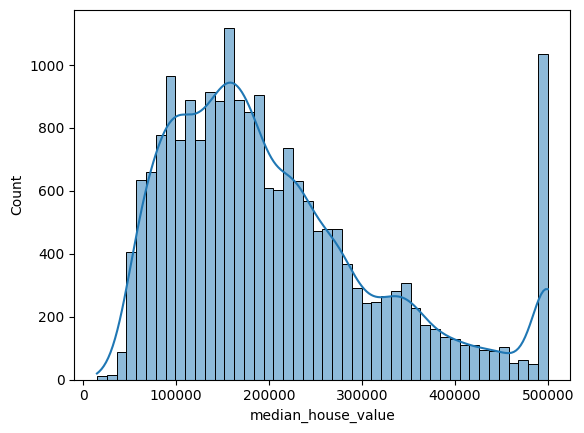

In [56]:
sns.histplot(housing_dataset['median_house_value'], kde=True)

In [57]:
skewness = housing_dataset['median_house_value'].skew()
print(f"Skewness of median_house_value: {skewness:.2f}")

Skewness of median_house_value: 0.98


In [58]:
# This plot above tells us that the median house value is right skewed having majority of houses in lower median values, with fewer houses having very high medium values

*Feature Distribution*

<Axes: xlabel='median_income', ylabel='Count'>

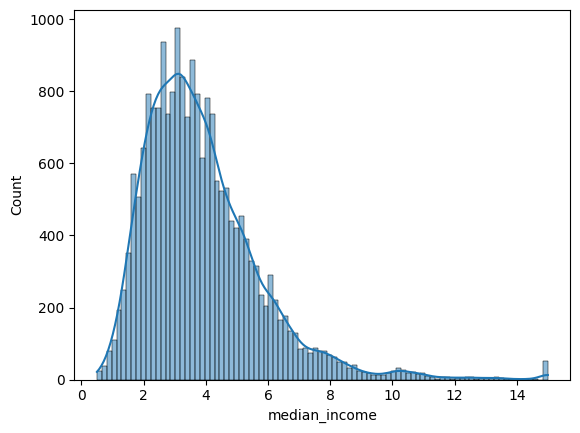

In [59]:
sns.histplot(housing_dataset['median_income'], kde=True)

In [60]:
skewness = housing_dataset['median_income'].skew()
print(f"Skewness of median_income: {skewness:.2f}")

Skewness of median_income: 1.65


In [61]:
# This plot above also tells us that the median income is right skewed having majority of areas having lower to moderate median income

<Axes: xlabel='total_rooms', ylabel='Count'>

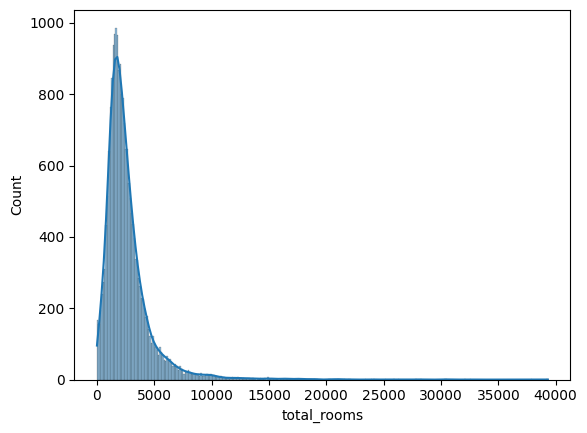

In [62]:
sns.histplot(housing_dataset['total_rooms'], kde=True)

In [63]:
skewness = housing_dataset['total_rooms'].skew()
print(f"Skewness of median_income: {skewness:.2f}")

Skewness of median_income: 4.15


<Axes: xlabel='population', ylabel='Count'>

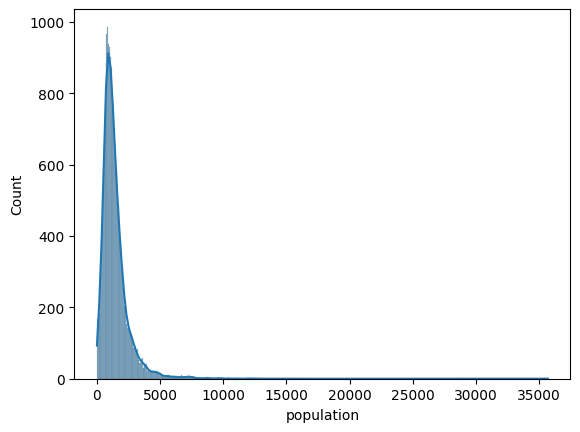

In [64]:
sns.histplot(housing_dataset['population'], kde=True)

In [65]:
skewness = housing_dataset['population'].skew()
print(f"Skewness of median_income: {skewness:.2f}")

Skewness of median_income: 4.94


<Axes: xlabel='total_bedrooms', ylabel='Count'>

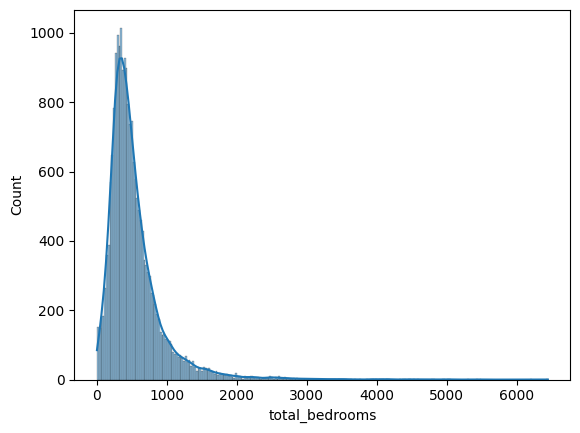

In [66]:
sns.histplot(housing_dataset['total_bedrooms'], kde=True)

In [67]:
skewness = housing_dataset['total_bedrooms'].skew()
print(f"Skewness of median_income: {skewness:.2f}")

Skewness of median_income: 3.46


In [68]:
# total_rooms, total_bedrooms, and population: These features are also heavily right-skewed, implying that most districts have a lower number of total rooms, total bedrooms, and population, with only a few districts having very large numbers for these attributes.

*Relationship with Target*

<Axes: >

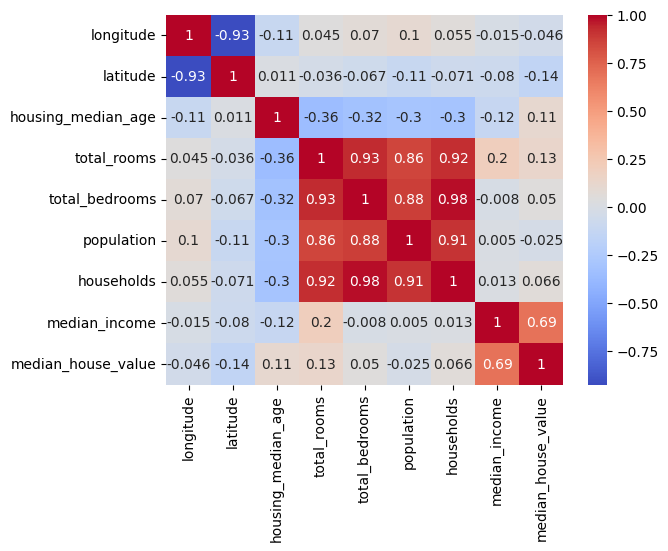

In [69]:
sns.heatmap(housing_dataset.corr(numeric_only=True).round(3), annot=True, cmap='coolwarm')

In [70]:
# Since by the above correlation, the median income shows the strongest positive correlation with the median house value
# Then the housing median age shows the moderate positive correlation with the median house value
# Then the total rooms, total bedrooms and households shows the weak positive correlation with the median house value
# While the population shows the weak negative correlation with the median house value

*Geographical Insight*

In [71]:
median_values_by_proximity = housing_dataset.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False).reset_index()
median_values_by_proximity

,ocean_proximity,median_house_value
0,ISLAND,380440.000000
1,NEAR BAY,259212.311790
2,NEAR OCEAN,249433.977427
3,<1H OCEAN,240084.285464
4,INLAND,124805.392001


/tmp/ipython-input-936765873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ocean_proximity', y='median_house_value', data=median_values_by_proximity, palette='viridis')


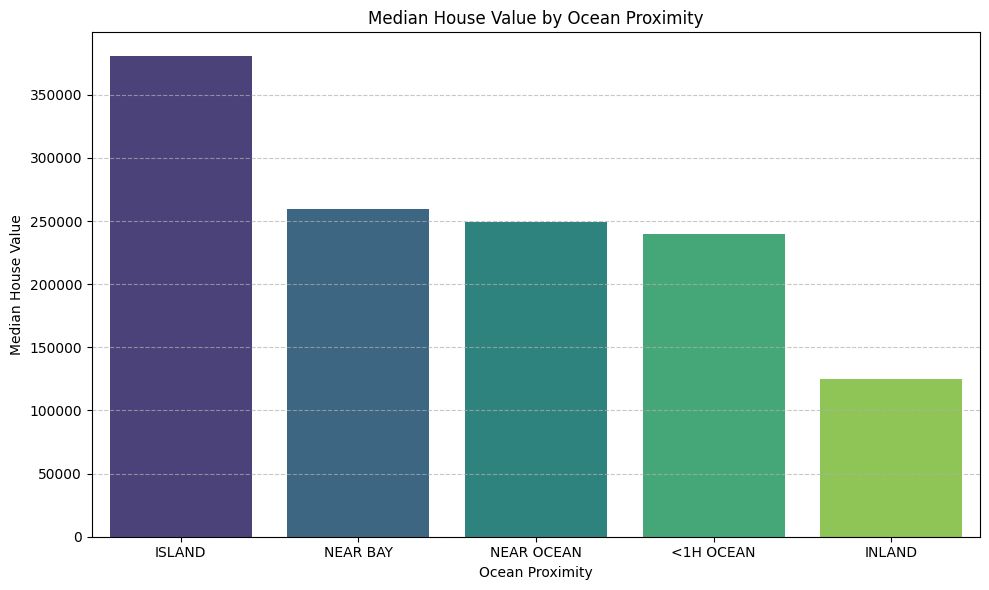

In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(x='ocean_proximity', y='median_house_value', data=median_values_by_proximity, palette='viridis')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.title('Median House Value by Ocean Proximity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [73]:
# Since the island has the highest median house value amongst the ocean proximity, followed by the near bay, near ocean and <1H ocean and the lowest one is inland

Feature Engineering

In [74]:
# Creating new features based on previous ones
housing_dataset['rooms_per_household'] = housing_dataset['total_rooms'] / housing_dataset['households']
housing_dataset['bedrooms_per_room'] = housing_dataset['total_bedrooms'] / housing_dataset['total_rooms']
housing_dataset['population_per_household'] = housing_dataset['population'] / housing_dataset['households']

In [75]:
# now checking the newly created features
housing_dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


Splitting the target & the features

In [77]:
housing_target = housing_dataset['median_house_value']
housing_features = housing_dataset.drop('median_house_value', axis=1)

Identify Feature Types

In [78]:
num_features = housing_features.drop('ocean_proximity', axis=1).columns.to_list()
cat_features = ['ocean_proximity']

Building Preprocessing Pipelines

Numerical Pipelines

In [83]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Categorical Pipeline

In [84]:
cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Combine Pipelines

In [85]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

Full ML pipeline (Preprocessing + Model)

In [87]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

Splitting the Data into training and testing

In [130]:
X_train, X_test, y_train, y_test = train_test_split(housing_features, housing_target, test_size=0.3, random_state=42)

Fitting the training data into the pipeline

In [131]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'rooms_per_household',
                                                   'bedrooms_per_room',
                                                   'population_per_household']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

Taking Predictions

In [132]:
y_pred = full_pipeline.predict(X_test)

Model Evaluation

In [133]:
y_train_pred = full_pipeline.predict(X_train)

# Checking mean absolute error, root mean squared error and r2 score for evaluation
mae = mean_absolute_error(y_train, y_train_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("Training data metrics")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Training data metrics
MAE: 48883.34934278918
RMSE: 67881.61208813675
R² Score: 0.6560478394225187


In [134]:
# Checking mean absolute error, root mean squared error and r2 score for evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Testing data metrics")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Testing data metrics
MAE: 49170.027044622206
RMSE: 67976.38462807174
R² Score: 0.6479506538813637


Saving the Pipeline

In [136]:
joblib.dump(full_pipeline, 'california_housing_pipeline.pkl')

['california_housing_pipeline.pkl']

Loading for New Predictions

In [ ]:
pipeline = joblib.load('california_housing_pipeline.pkl')
 
new_data = pd.DataFrame({
    'longitude': [-122.23	],
    'latitude': [37.88],
    'housing_median_age': [41],
    'total_rooms': [880],
    'total_bedrooms': [129],
    'population': [322],
    'households': [126],
    'median_income': [8.3252],
    'ocean_proximity': ['NEAR BAY']
})

new_data['rooms_per_household'] = new_data['total_rooms'] / new_data['households']
new_data['bedrooms_per_room'] = new_data['total_bedrooms'] / new_data['total_rooms']
new_data['population_per_household'] = new_data['population'] / new_data['households']

prediction = pipeline.predict(new_data)
print("Predicted House Price:", prediction[0])


Predicted House Price: 406282.8292091979
